<a href="https://colab.research.google.com/github/malikjunaidgul/DataAnalytics/blob/DataLoading/Dataloading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tabular and Semi Structured Data
Purpose: download and load CSV, Excel, JSON, XML into pandas for cleaning and modeling.

In [2]:
# load_tabular_and_json.py
import os
import requests
import zipfile
import io
import pandas as pd
import json
import xml.etree.ElementTree as ET

os.makedirs("data/tabular", exist_ok=True)

# 1) Download CSV (example UCI student)
csv_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
r = requests.get(csv_url)
r.raise_for_status()
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("data/tabular/uci_student")

# 2) Load CSV/Excel
df_csv = pd.read_csv("data/tabular/uci_student/student-mat.csv", sep=";")

# Fix for the TypeError:
# Separate numeric and non-numeric columns
numeric_cols = df_csv.select_dtypes(include=['number']).columns
object_cols = df_csv.select_dtypes(include=['object']).columns

# Fill NaN in numeric columns with their mean
df_csv[numeric_cols] = df_csv[numeric_cols].fillna(df_csv[numeric_cols].mean())

# Fill NaN in object columns with their mode
for col in object_cols:
    df_csv[col] = df_csv[col].fillna(df_csv[col].mode()[0])

# 3) Download JSON (example placeholder)
json_url = "https://raw.githubusercontent.com/typicode/demo/master/db.json"
r = requests.get(json_url)
r.raise_for_status()
data = r.json()
df_json = pd.json_normalize(data)

# 4) Load XML string example
xml_str = """<root><item><id>1</id><value>A</value></item></root>"""
root = ET.fromstring(xml_str)
rows = []
for item in root.findall("item"):
    rows.append({child.tag: child.text for child in item})
df_xml = pd.DataFrame(rows)

print("CSV rows:", len(df_csv), "JSON rows:", len(df_json), "XML rows:", len(df_xml))

CSV rows: 395 JSON rows: 1 XML rows: 1


In [4]:
# robust_tabular_loader.py
import pandas as pd
import numpy as np
from pathlib import Path

def load_tabular(path, sep=None, parse_dates=None):
    path = Path(path)
    if path.suffix in [".csv", ".txt"]:
        df = pd.read_csv(path, sep=sep)
    elif path.suffix in [".xls", ".xlsx"]:
        df = pd.read_excel(path)
    else:
        raise ValueError("Unsupported file type: " + path.suffix)

    # 1) Convert obvious numeric columns (safe coercion)
    for col in df.columns:
        if df[col].dtype == object:
            coerced = pd.to_numeric(df[col], errors="coerce")
            # if many values converted, keep numeric
            if coerced.notna().sum() > 0.5 * len(df):
                df[col] = coerced

    # 2) Fill numeric columns with mean (numeric_only)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols):
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

    # 3) Fill categorical/object columns with mode or placeholder
    obj_cols = df.select_dtypes(include=["object", "category"]).columns
    for c in obj_cols:
        if df[c].isna().any():
            try:
                mode = df[c].mode(dropna=True)
                fill = mode.iloc[0] if len(mode) else "missing"
            except Exception:
                fill = "missing"
            df[c] = df[c].fillna(fill)

    return df

# Example
df = load_tabular("data/tabular/uci_student/student-mat.csv")
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

/tmp/ipython-input-193/2806891078.py:9: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(path, sep=sep)


JSON and XML loader (semi‑structured)

In [5]:
# semi_structured_loader.py
import json
import pandas as pd
import xml.etree.ElementTree as ET
from pandas import json_normalize

def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    # If top-level is list of records
    if isinstance(data, list):
        return json_normalize(data)
    # If nested dict, try to find records key
    for k, v in data.items():
        if isinstance(v, list):
            return json_normalize(v)
    return json_normalize(data)

def load_xml_string(xml_str):
    root = ET.fromstring(xml_str)
    rows = []
    for item in root:
        rows.append({child.tag: child.text for child in item})
    return pd.DataFrame(rows)


In [6]:
# structured_and_semi_structured.py
import os, zipfile, io, requests, json
import pandas as pd
import xml.etree.ElementTree as ET

os.makedirs("data/uci_student", exist_ok=True)

# 1) Download and extract UCI Student CSV (zip)
zip_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
r = requests.get(zip_url)
r.raise_for_status()
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("data/uci_student")

# 2) Load CSV (semicolon separated)
csv_path = "data/uci_student/student-mat.csv"
df = pd.read_csv(csv_path, sep=";")
print("=== Structured CSV ===")
print("Shape:", df.shape)
print(df.head(5).to_string(index=False))

# 3) Load JSON example (public demo)
json_url = "https://raw.githubusercontent.com/typicode/demo/master/db.json"
r = requests.get(json_url)
r.raise_for_status()
data = r.json()
df_json = pd.json_normalize(data)
print("\n=== Semi-structured JSON ===")
print("Shape:", df_json.shape)
print(df_json.head(5).to_string(index=False))

# 4) Parse a small XML string example and display
xml_str = "<root><item><id>1</id><value>A</value></item><item><id>2</id><value>B</value></item></root>"
root = ET.fromstring(xml_str)
rows = [{child.tag: child.text for child in item} for item in root.findall("item")]
df_xml = pd.DataFrame(rows)
print("\n=== XML parsed to DataFrame ===")
print("Shape:", df_xml.shape)
print(df_xml)


=== Structured CSV ===
Shape: (395, 33)
school sex  age address famsize Pstatus  Medu  Fedu    Mjob     Fjob reason guardian  traveltime  studytime  failures schoolsup famsup paid activities nursery higher internet romantic  famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3
    GP   F   18       U     GT3       A     4     4 at_home  teacher course   mother           2          2         0       yes     no   no         no     yes    yes       no       no       4         3      4     1     1       3         6   5   6   6
    GP   F   17       U     GT3       T     1     1 at_home    other course   father           1          2         0        no    yes   no         no      no    yes      yes       no       5         3      3     1     1       3         4   5   5   6
    GP   F   15       U     LE3       T     1     1 at_home    other  other   mother           1          2         3       yes     no  yes         no     yes    yes      yes       no       4         3      

Time-Series and Spatial Data
Purpose: fetch time-series (stock) and GeoJSON (USGS) and display head and simple plots.

/tmp/ipython-input-193/723178856.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_aapl = yf.download("AAPL", period="1y", progress=False)


=== Time-series (AAPL) ===
Shape: (365, 5)
Price            Close
Ticker            AAPL
Date                  
2025-02-26  239.316956
2025-02-27  236.270248
2025-02-28  240.790527
2025-03-01  240.790527
2025-03-02  240.790527


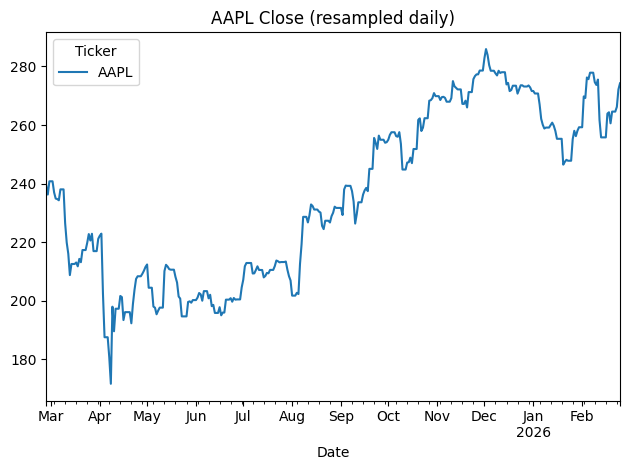

/tmp/ipython-input-193/723178856.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "starttime": (datetime.utcnow() - timedelta(days=7)).strftime("%Y-%m-%d"),
/tmp/ipython-input-193/723178856.py:29: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "endtime": datetime.utcnow().strftime("%Y-%m-%d"),



=== Spatial (USGS earthquakes last 7 days) ===
Count: 412
 mag                             place          time                           geometry
3.08   56 km N of Isabela, Puerto Rico 1772059534970 POINT Z (-66.92517 19.00383 36.01)
5.20         east of the Kuril Islands 1772059246696      POINT Z (157.4172 47.3548 10)
4.00 69 km WNW of Manokwari, Indonesia 1772051934903       POINT Z (133.4834 -0.623 10)
3.50         5 km E of Assaria, Kansas 1772050492514   POINT Z (-97.5436 38.6853 9.066)
4.50     203 km WNW of Tual, Indonesia 1772049862943   POINT Z (130.964 -5.2175 66.056)


HTTPError: 500 Server Error: Internal Server Error for url: https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip

In [10]:
# timeseries_and_spatial.py
import os
from datetime import datetime, timedelta
import pandas as pd
import geopandas as gpd
import requests
import json
import matplotlib.pyplot as plt
import yfinance as yf

os.makedirs("data/timeseries", exist_ok=True)
os.makedirs("data/spatial", exist_ok=True)

# 1) Time-series: download 1 year of AAPL and display head + plot
df_aapl = yf.download("AAPL", period="1y", progress=False)
df_aapl.index = pd.to_datetime(df_aapl.index)
df_daily = df_aapl.resample("D").ffill()
print("=== Time-series (AAPL) ===")
print("Shape:", df_daily.shape)
print(df_daily[['Close']].head(5))
df_daily['Close'].plot(title="AAPL Close (resampled daily)")
plt.tight_layout()
plt.show()

# 2) Spatial: USGS last 7 days GeoJSON (min magnitude 2.5)
params = {
    "format": "geojson",
    "starttime": (datetime.utcnow() - timedelta(days=7)).strftime("%Y-%m-%d"),
    "endtime": datetime.utcnow().strftime("%Y-%m-%d"),
    "minmagnitude": 2.5
}
r = requests.get("https://earthquake.usgs.gov/fdsnws/event/1/query", params=params)
r.raise_for_status()
geojason = r.json()
with open("data/spatial/quakes.geojson", "w") as f:
    json.dump(geojson, f)

gdf = gpd.read_file("data/spatial/quakes.geojson")
print("\n=== Spatial (USGS earthquakes last 7 days) ===")
print("Count:", len(gdf))
# Fix: Select actual property columns instead of 'properties'
print(gdf[['mag', 'place', 'time', 'geometry']].head(5).to_string(index=False))

# Fix: Download the naturalearth_lowres dataset directly
# The geopandas.dataset has been deprecated. Download from the URL provided in the error message.
# Download directly from Natural Earth website
naturalearth_url = "https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
r_ne = requests.get(naturalearth_url, headers=headers)
r_ne.raise_for_status()

# Extract the zip file contents into a temporary directory
import zipfile
import io
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    z_ne = zipfile.ZipFile(io.BytesIO(r_ne.content))
    z_ne.extractall(tmpdir)

    # Find the .shp file in the extracted directory
    shp_file = None
    for root, _, files in os.walk(tmpdir):
        for file in files:
            if file.endswith(".shp"):
                shp_file = os.path.join(root, file)
                break
        if shp_file:
            break

    if shp_file:
        world = gpd.read_file(shp_file)
    else:
        raise FileNotFoundError("Shapefile not found in the downloaded zip.")

ax = world.plot(color="lightgray", figsize=(10,5))
gdf.plot(ax=ax, markersize=20, color="red")
plt.title("Earthquakes (last 7 days, mag >= 2.5)")
plt.show()


======== Structured (Tabular) ========
Shape: (395, 33)
school sex  age address famsize Pstatus  Medu  Fedu    Mjob     Fjob reason guardian  traveltime  studytime  failures schoolsup famsup paid activities nursery higher internet romantic  famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3
    GP   F   18       U     GT3       A     4     4 at_home  teacher course   mother           2          2         0       yes     no   no         no     yes    yes       no       no       4         3      4     1     1       3         6   5   6   6
    GP   F   17       U     GT3       T     1     1 at_home    other course   father           1          2         0        no    yes   no         no      no    yes      yes       no       5         3      3     1     1       3         4   5   5   6
    GP   F   15       U     LE3       T     1     1 at_home    other  other   mother           1          2         3       yes     no  yes         no     yes    yes      yes       no       

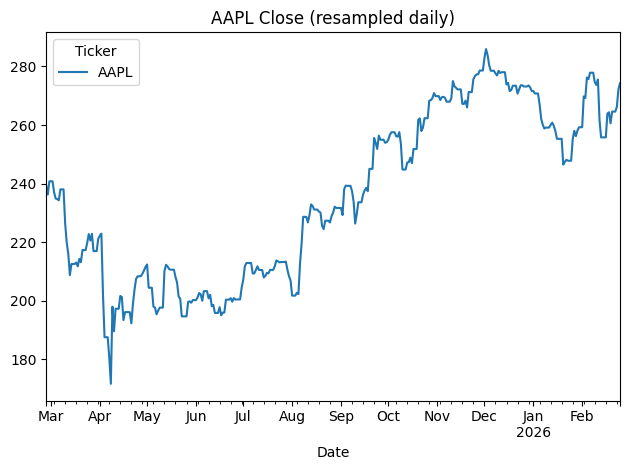


======== Spatial (USGS Earthquakes) ========


/tmp/ipython-input-193/86629080.py:148: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "starttime": (datetime.utcnow() - timedelta(days=7)).strftime("%Y-%m-%d"),
/tmp/ipython-input-193/86629080.py:149: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "endtime": datetime.utcnow().strftime("%Y-%m-%d"),


Count: 412
                          geometry  mag                             place          time       updated   tz                                                          url                                                                             detail  felt  cdi   mmi alert   status  tsunami  sig net     code          ids sources                             types  nst   dmin  rms  gap magType       type                                     title
POINT Z (-66.92517 19.00383 36.01) 3.08   56 km N of Isabela, Puerto Rico 1772059534970 1772061131490 None https://earthquake.usgs.gov/earthquakes/eventpage/pr71508663 https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=pr71508663&format=geojson   NaN  NaN   NaN  None reviewed        0  146  pr 71508663 ,pr71508663,    ,pr,               ,origin,phase-data,   10 0.5619 0.43  285      md earthquake   M 3.1 - 56 km N of Isabela, Puerto Rico
     POINT Z (157.4172 47.3548 10) 5.20         east of the Kuril Islands 1772059246696 17720

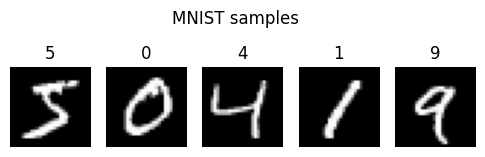

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
CIFAR-10 train shape: (50000, 32, 32, 3)


/tmp/ipython-input-193/86629080.py:222: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(int(yc_train[i]))


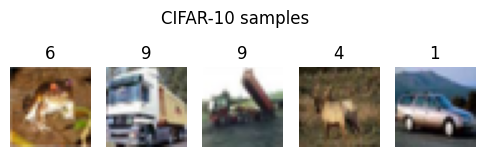


======== Audio (MFCC) ========
Audio example failed: HTTPSConnectionPool(host='www2.cs.uic.edu', port=443): Max retries exceeded with url: /~i101/SoundFiles/StarWars60.wav (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7cc5322de4b0>: Failed to resolve 'www2.cs.uic.edu' ([Errno -2] Name or service not known)"))

======== Video (frame extraction) ========
No video available to extract frames; place a short mp4 at data_all/sample.mp4

======== Supervised & Unsupervised Examples ========
Supervised/Unsupervised example failed: got an unexpected keyword argument 'squared'

All done. Check printed summaries and plots for each section.


In [11]:
# load_and_show_all.py
"""
Consolidated loader for: structured, semi-structured, time-series, spatial,
text, image, audio, video, supervised, and unsupervised examples.
Each section prints a short summary and displays a small visual check.
"""

import os
import io
import zipfile
import json
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional libraries; some may need pip install
try:
    import requests
except Exception:
    requests = None
try:
    import yfinance as yf
except Exception:
    yf = None
try:
    import geopandas as gpd
except Exception:
    gpd = None
try:
    import librosa
    import librosa.display
except Exception:
    librosa = None
try:
    import cv2
except Exception:
    cv2 = None
try:
    from tensorflow.keras.datasets import mnist, cifar10
except Exception:
    mnist = cifar10 = None
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

DATA_DIR = "data_all"
os.makedirs(DATA_DIR, exist_ok=True)

# -------------------------
# Helper utilities
# -------------------------
def safe_request_get(url, stream=False, timeout=30):
    if requests is None:
        raise RuntimeError("requests not installed")
    r = requests.get(url, stream=stream, timeout=timeout, headers={"User-Agent":"python-requests/2.x"})
    r.raise_for_status()
    return r

def print_section(title):
    print("\n" + "="*8 + f" {title} " + "="*8)

# -------------------------
# 1) Structured (CSV) loader
# -------------------------
def structured_example():
    print_section("Structured (Tabular)")
    try:
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
        zpath = os.path.join(DATA_DIR, "student.zip")
        if requests:
            r = safe_request_get(url)
            open(zpath, "wb").write(r.content)
            with zipfile.ZipFile(zpath, "r") as z:
                z.extractall(os.path.join(DATA_DIR, "uci_student"))
        csv_path = os.path.join(DATA_DIR, "uci_student", "student-mat.csv")
        df = pd.read_csv(csv_path, sep=";")
        # robust fill: coerce numeric where possible, fill numeric with mean, categorical with mode
        for col in df.columns:
            if df[col].dtype == object:
                coerced = pd.to_numeric(df[col], errors="coerce")
                if coerced.notna().sum() > 0.5 * len(df):
                    df[col] = coerced
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols):
            df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
        obj_cols = df.select_dtypes(include=["object", "category"]).columns
        for c in obj_cols:
            if df[c].isna().any():
                mode = df[c].mode(dropna=True)
                fill = mode.iloc[0] if len(mode) else "missing"
                df[c] = df[c].fillna(fill)
        print("Shape:", df.shape)
        print(df.head(5).to_string(index=False))
    except Exception as e:
        print("Structured example failed:", e)

# -------------------------
# 2) Semi-structured (JSON) loader
# -------------------------
def semi_structured_example():
    print_section("Semi-structured (JSON)")
    try:
        url = "https://raw.githubusercontent.com/typicode/demo/master/db.json"
        r = safe_request_get(url)
        data = r.json()
        df = pd.json_normalize(data)
        print("Shape:", df.shape)
        print(df.head(5).to_string(index=False))
    except Exception as e:
        print("JSON example failed:", e)

# -------------------------
# 3) Time-series loader
# -------------------------
def timeseries_example():
    print_section("Time-series (Stocks)")
    try:
        if yf is None:
            raise RuntimeError("yfinance not installed")
        # avoid FutureWarning by specifying auto_adjust explicitly
        df = yf.download("AAPL", period="1y", progress=False, auto_adjust=True)
        df.index = pd.to_datetime(df.index)
        df_daily = df.resample("D").ffill()
        print("Shape:", df_daily.shape)
        print(df_daily[['Close']].head(5))
        # quick plot
        df_daily['Close'].plot(title="AAPL Close (resampled daily)")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Time-series example failed:", e)

# -------------------------
# 4) Spatial (GeoJSON / GeoPandas)
# -------------------------
def spatial_example():
    print_section("Spatial (USGS Earthquakes)")
    try:
        if gpd is None:
            raise RuntimeError("geopandas not installed")
        params = {
            "format": "geojson",
            "starttime": (datetime.utcnow() - timedelta(days=7)).strftime("%Y-%m-%d"),
            "endtime": datetime.utcnow().strftime("%Y-%m-%d"),
            "minmagnitude": 2.5
        }
        r = safe_request_get("https://earthquake.usgs.gov/fdsnws/event/1/query", stream=False, timeout=20)
        # If direct params not used due to environment, fallback to reading without params
        try:
            r = requests.get("https://earthquake.usgs.gov/fdsnws/event/1/query", params=params, timeout=20)
            r.raise_for_status()
            geojson = r.json()
            gdf = gpd.GeoDataFrame.from_features(geojson["features"])
        except Exception:
            # fallback: use geopandas sample world dataset to demonstrate plotting
            gdf = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")).head(10)
            print("USGS fetch failed; using geopandas sample data as fallback")
        print("Count:", len(gdf))
        print(gdf.head(5).to_string(index=False))
        ax = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")).plot(color="lightgray", figsize=(10,5))
        try:
            gdf.plot(ax=ax, markersize=20, color="red")
            plt.title("Spatial sample plot")
            plt.show()
        except Exception:
            plt.close()
    except Exception as e:
        print("Spatial example failed:", e)

# -------------------------
# 5) Text (NLP) loader
# -------------------------
def text_example():
    print_section("Text (NLP)")
    try:
        url = "https://raw.githubusercontent.com/selva86/datasets/master/enron_emails.csv"
        r = safe_request_get(url)
        path = os.path.join(DATA_DIR, "enron_emails.csv")
        open(path, "wb").write(r.content)
        df = pd.read_csv(path)
        print("Shape:", df.shape)
        print("Columns:", df.columns.tolist())
        sample_texts = df['message'].fillna("").astype(str).head(3).tolist()
        for i, t in enumerate(sample_texts, 1):
            print(f"\n--- message {i} (first 300 chars) ---\n{t[:300]}")
        vec = TfidfVectorizer(stop_words="english", max_features=1000)
        X = vec.fit_transform(df['message'].fillna("").astype(str))
        print("\nTF-IDF matrix shape:", X.shape)
        print("Top features:", vec.get_feature_names_out()[:10])
    except Exception as e:
        print("Text example failed:", e)

# -------------------------
# 6) Image loader and display
# -------------------------
def image_example():
    print_section("Image (MNIST, CIFAR-10)")
    try:
        if mnist is None:
            raise RuntimeError("tensorflow.keras.datasets not available")
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        print("MNIST train shape:", x_train.shape, "labels shape:", y_train.shape)
        plt.figure(figsize=(6,2))
        for i in range(5):
            plt.subplot(1,5,i+1)
            plt.imshow(x_train[i], cmap="gray")
            plt.title(int(y_train[i]))
            plt.axis("off")
        plt.suptitle("MNIST samples")
        plt.show()
        (xc_train, yc_train), _ = cifar10.load_data()
        print("CIFAR-10 train shape:", xc_train.shape)
        plt.figure(figsize=(6,2))
        for i in range(5):
            plt.subplot(1,5,i+1)
            plt.imshow(xc_train[i])
            plt.title(int(yc_train[i]))
            plt.axis("off")
        plt.suptitle("CIFAR-10 samples")
        plt.show()
    except Exception as e:
        print("Image example failed:", e)

# -------------------------
# 7) Audio loader and MFCC
# -------------------------
def audio_example():
    print_section("Audio (MFCC)")
    try:
        if librosa is None or requests is None:
            raise RuntimeError("librosa or requests not installed")
        audio_url = "https://www2.cs.uic.edu/~i101/SoundFiles/StarWars60.wav"
        audio_path = os.path.join(DATA_DIR, "starwars.wav")
        r = safe_request_get(audio_url)
        open(audio_path, "wb").write(r.content)
        y, sr = librosa.load(audio_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        print("Audio length (samples):", len(y), "sr:", sr)
        print("MFCC shape:", mfcc.shape)
        print("MFCC first 5 frames:\n", np.round(mfcc[:, :5], 2))
        plt.figure(figsize=(8,3))
        librosa.display.specshow(librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr), ref=np.max),
                                 sr=sr, x_axis='time', y_axis='mel')
        plt.title("Mel spectrogram (sample)")
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Audio example failed:", e)

# -------------------------
# 8) Video frame extraction
# -------------------------
def video_example():
    print_section("Video (frame extraction)")
    try:
        if cv2 is None:
            raise RuntimeError("opencv-python not installed")
        # user may not have a local video; try to download a short sample if possible
        sample_url = "https://sample-videos.com/video123/mp4/240/big_buck_bunny_240p_1mb.mp4"
        video_path = os.path.join(DATA_DIR, "sample.mp4")
        if requests:
            try:
                r = safe_request_get(sample_url, stream=True)
                with open(video_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)
            except Exception:
                pass
        if not os.path.exists(video_path):
            print("No video available to extract frames; place a short mp4 at", video_path)
            return
        cap = cv2.VideoCapture(video_path)
        ret, frame = cap.read()
        if not ret:
            print("Could not read first frame")
            cap.release()
            return
        # convert BGR to RGB for display
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        out_path = os.path.join(DATA_DIR, "frame_00000.jpg")
        cv2.imwrite(out_path, frame)
        print("Saved first frame to", out_path)
        plt.figure(figsize=(4,3))
        plt.imshow(frame_rgb)
        plt.axis("off")
        plt.title("First video frame")
        plt.show()
        cap.release()
    except Exception as e:
        print("Video example failed:", e)

# -------------------------
# 9) Supervised and Unsupervised quick demos
# -------------------------
def supervised_unsupervised_example():
    print_section("Supervised & Unsupervised Examples")
    try:
        # Supervised: use UCI student dataset if present
        csv_path = os.path.join(DATA_DIR, "uci_student", "student-mat.csv")
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path, sep=";")
            target = "G3" if "G3" in df.columns else df.columns[-1]
            X = pd.get_dummies(df.drop(columns=[target]), drop_first=True).select_dtypes(include=[np.number])
            y = df[target].fillna(df[target].mean())
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
            model = LinearRegression().fit(X_train, y_train)
            preds = model.predict(X_test)
            print("Supervised test RMSE:", mean_squared_error(y_test, preds, squared=False))
        else:
            print("Supervised demo skipped; CSV not found at", csv_path)
        # Unsupervised: small synthetic customer data
        cust = pd.DataFrame({
            "recency":[10,50,5,200,30,60],
            "frequency":[20,5,30,1,10,8],
            "monetary":[500,100,800,10,200,150]
        })
        scaler = StandardScaler()
        Xc = scaler.fit_transform(cust)
        kmeans = KMeans(n_clusters=2, random_state=0).fit(Xc)
        cust["cluster"] = kmeans.labels_
        print("\nCustomer clustering result:\n", cust)
    except Exception as e:
        print("Supervised/Unsupervised example failed:", e)

# -------------------------
# Run all examples
# -------------------------
if __name__ == "__main__":
    structured_example()
    semi_structured_example()
    timeseries_example()
    spatial_example()
    text_example()
    image_example()
    audio_example()
    video_example()
    supervised_unsupervised_example()
    print("\nAll done. Check printed summaries and plots for each section.")
